### 1. colab 연동

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchsummary import summary
import torch.optim.lr_scheduler as lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # CIFAR-100 평균/표준편차
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class names: {train_dataset.classes}')
print(f'Example image shape: {train_dataset[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [3]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNetOriginal(nn.Module):
    def __init__(self, block, num_blocks, num_classes=1000):
        super(ResNetOriginal, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

In [4]:
def ResNet18(num_classes=1000):
    return ResNetOriginal(BasicBlock, [2, 2, 2, 2], num_classes)

def ResNet50(num_classes=1000):
    return ResNetOriginal(Bottleneck, [3, 4, 6, 3], num_classes)

def ResNet101(num_classes=1000):
    return ResNetOriginal(Bottleneck, [3, 4, 23, 3], num_classes)

summary(ResNet18().to(device), (3,32,32))
summary(ResNet50().to(device), (3,32,32))
summary(ResNet101().to(device), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          36,864
       BatchNorm2d-8           [-1, 64, 32, 32]             128
              ReLU-9           [-1, 64, 32, 32]               0
       BasicBlock-10           [-1, 64, 32, 32]               0
           Conv2d-11           [-1, 64, 32, 32]          36,864
      BatchNorm2d-12           [-1, 64, 32, 32]             128
             ReLU-13           [-1, 64, 32, 32]               0
           Conv2d-14           [-1, 64,

### 4. train, test 함수 정의

In [5]:
def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)
    model.train()
    epoch_loss , epoch_correct = 0 , 0

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)

        loss = loss_fn(output_, target_)
        loss.backward()
        optimizer.step()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches

In [6]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. log 및 모델 정의

In [7]:
train_logs = { "ResNet18_acc":[],
                "ResNet50_acc":[],
                "ResNet101_acc":[],
                }
test_logs = { "ResNet18_acc":[],
                "ResNet50_acc":[],
                "ResNet101_acc":[],
                }

models = {
    "ResNet18": ResNet18().to(device),
    "ResNet50": ResNet50().to(device),
    "ResNet101": ResNet101().to(device),
}

### 6. 학습

In [8]:
from tqdm.notebook import tqdm
EPOCHS = 30
criterion = nn.CrossEntropyLoss()

# ResNet18 학습-----------------------------------------------------------------
current_model = models["ResNet18"]
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('ResNet18')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    if(epoch%5 == 0 or epoch == EPOCHS - 1):
        print(f'ResNet18_train_acc:{train_acc:.4f} ResNet18_test_acc:{test_acc:.4f}')

    train_logs["ResNet18_acc"].append(train_acc)
    test_logs["ResNet18_acc"].append(test_acc)

ResNet18


  0%|          | 0/30 [00:00<?, ?it/s]

ResNet18_train_acc:0.1539 ResNet18_test_acc:0.2066
ResNet18_train_acc:0.5720 ResNet18_test_acc:0.5116
ResNet18_train_acc:0.7080 ResNet18_test_acc:0.6251
ResNet18_train_acc:0.8099 ResNet18_test_acc:0.6659
ResNet18_train_acc:0.9040 ResNet18_test_acc:0.7008
ResNet18_train_acc:0.9577 ResNet18_test_acc:0.7177
ResNet18_train_acc:0.9697 ResNet18_test_acc:0.7176


In [9]:
# ResNet50 학습-----------------------------------------------------------------
current_model = models["ResNet50"]
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('ResNet50')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    if(epoch%5 == 0 or epoch == EPOCHS - 1):
        print(f'ResNet50_train_acc:{train_acc:.4f} ResNet50_test_acc:{test_acc:.4f}')

    train_logs["ResNet50_acc"].append(train_acc)
    test_logs["ResNet50_acc"].append(test_acc)

ResNet50


  0%|          | 0/30 [00:00<?, ?it/s]

ResNet50_train_acc:0.1179 ResNet50_test_acc:0.1836
ResNet50_train_acc:0.5033 ResNet50_test_acc:0.4939
ResNet50_train_acc:0.6683 ResNet50_test_acc:0.5926
ResNet50_train_acc:0.7891 ResNet50_test_acc:0.6412
ResNet50_train_acc:0.9036 ResNet50_test_acc:0.6790
ResNet50_train_acc:0.9687 ResNet50_test_acc:0.7061
ResNet50_train_acc:0.9783 ResNet50_test_acc:0.7081


In [10]:
# ResNet101 학습-----------------------------------------------------------------
current_model = models["ResNet101"]
optimizer = optim.SGD(current_model.parameters(), 1e-2, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('='*50)
print('ResNet101')
for epoch in tqdm(range(EPOCHS)):
    train_acc, train_loss = train(train_loader, current_model, criterion, optimizer, scheduler)
    test_acc, test_loss = test(test_loader, current_model, criterion)

    if(epoch%5 == 0 or epoch == EPOCHS - 1):
        print(f'ResNet101_train_acc:{train_acc:.4f} ResNet101_test_acc:{test_acc:.4f}')

    train_logs["ResNet101_acc"].append(train_acc)
    test_logs["ResNet101_acc"].append(test_acc)

ResNet101


  0%|          | 0/30 [00:00<?, ?it/s]

ResNet101_train_acc:0.0949 ResNet101_test_acc:0.1546
ResNet101_train_acc:0.4456 ResNet101_test_acc:0.4391
ResNet101_train_acc:0.6287 ResNet101_test_acc:0.5781
ResNet101_train_acc:0.7572 ResNet101_test_acc:0.6139
ResNet101_train_acc:0.8876 ResNet101_test_acc:0.6718
ResNet101_train_acc:0.9656 ResNet101_test_acc:0.6950
ResNet101_train_acc:0.9791 ResNet101_test_acc:0.6977


### 7. 시각화

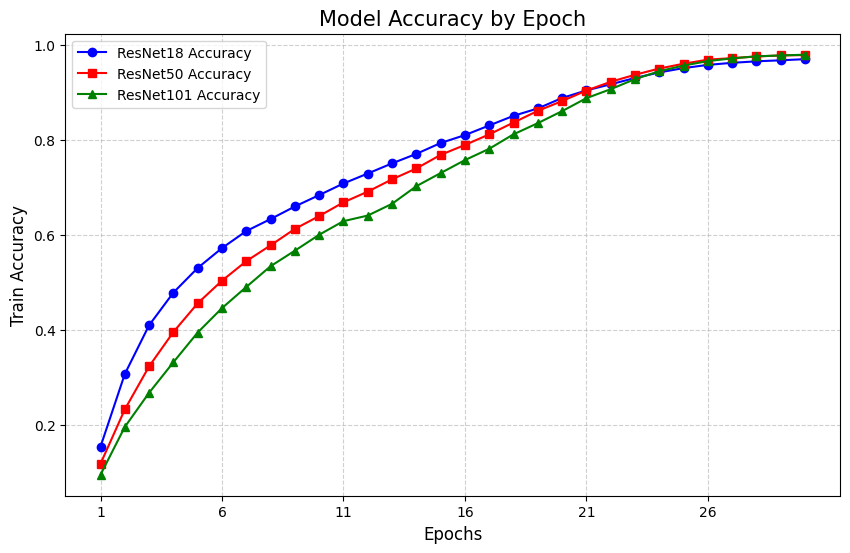

In [13]:
import matplotlib.pyplot as plt

# epoch별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, train_logs["ResNet18_acc"], 'b-o', label='ResNet18 Accuracy')
plt.plot(epochs, train_logs["ResNet50_acc"], 'r-s', label='ResNet50 Accuracy')
plt.plot(epochs, train_logs["ResNet101_acc"], 'g-^', label='ResNet101 Accuracy')
plt.xticks(range(1, EPOCHS + 1, 5))

plt.title(f'Model Accuracy by Epoch', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

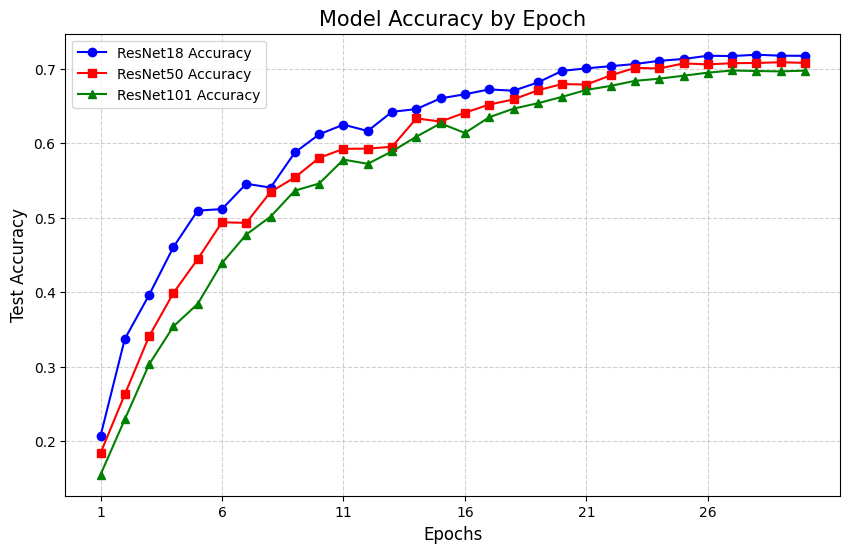

In [14]:
# epoch별 모델 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, test_logs["ResNet18_acc"], 'b-o', label='ResNet18 Accuracy')
plt.plot(epochs, test_logs["ResNet50_acc"], 'r-s', label='ResNet50 Accuracy')
plt.plot(epochs, test_logs["ResNet101_acc"], 'g-^', label='ResNet101 Accuracy')
plt.xticks(range(1, EPOCHS + 1, 5))

plt.title(f'Model Accuracy by Epoch', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()